# Import 

In [1]:

root = r"/zhome/2f/7/202918/phc_nzi"
src = r"/zhome/2f/7/202918/phc_nzi/src"
import sys
sys.path.append(root)
sys.path.append(src)

## Define the materials
from src.photonic_crystal_maker import (Material, Geometry, PhotonicCrystal, 
                                        ScriptParam, ScriptParamVector3, BaseDielectricDistribution,
                                        HexagonalLattice, SquareLattice)
import meep as mp
from src.mpb_configurator import *
from src.mpi_differential_evolution import MPIdeOptimizator
from src.simulation_handler import LSFJobConfiguration, MPBDataOptions, Simulation
from src.optimization_data_analyzer import OptimizationDataAnalyzer
from src.simulation_viewer import SimulationViewer
from src.lsf_sweeper import LSFSweeper

import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
plt.rcParams["font.size"] = 15



# K  Points Functions


In [2]:

def make_kpoints_vector3(kpoints):
    """
    Convert a list of k-points to a list of Vector3 objects.

    Parameters
    ----------
    kpoints : (N, 2) ndarray
        Array of (k_x, k_y) coordinates in reduced units.

    Returns
    -------
    kpoints_vector3 : list of mp.Vector3
        List of Vector3 objects representing the k-points.
    """
    return [mp.Vector3(k[0], k[1], 0) for k in kpoints]

def generate_ibz_kpoints(nx, ny, centered=False):
    """
    Generate k-points in the irreducible Brillouin zone (IBZ) 
    of a 2D square (C4v) lattice, ensuring (0,0) is included.

    Parameters
    ----------
    nx, ny : int
        Number of divisions along k_x and k_y in the full BZ grid.
        The actual number of points in the IBZ will be approximately nx*ny/8.
    centered : bool, default=False
        If True, use midpoints of each cell: k_i = (i+0.5)/N - 0.5.
        If False, use endpoints:       k_i = i/N       - 0.5.

    Returns
    -------
    ibz_kpts : (M, 2) ndarray
        Array of (k_x, k_y) coordinates in reduced units 
        lying in the IBZ wedge 0 ≤ k_y ≤ k_x ≤ 0.5, 
        with (0,0) always present.
    """
    # 1) Build full grid in the square BZ
    if centered:
        kx_vals = (np.arange(nx) + 0.5)/nx - 0.5
        ky_vals = (np.arange(ny) + 0.5)/ny - 0.5
    else:
        kx_vals = np.arange(nx)/nx - 0.5
        ky_vals = np.arange(ny)/ny - 0.5

    kxg, kyg = np.meshgrid(kx_vals, ky_vals, indexing='ij')
    all_pts = np.vstack([kxg.ravel(), kyg.ravel()]).T

    # 2) Select only the IBZ wedge: 0 ≤ ky ≤ kx ≤ 0.5
    mask = (all_pts[:,1] >= 0) & (all_pts[:,0] >= all_pts[:,1]) & (all_pts[:,0] <=  0.5)
    ibz_kpts = all_pts[mask]

    # 3) Sort (first by kx, then ky) for consistency
    ibz_kpts = ibz_kpts[np.lexsort((ibz_kpts[:,1], ibz_kpts[:,0]))]
    print("shape of kpoints: ", ibz_kpts.shape) 
    return ibz_kpts

def generate_bz_kpoints(nx, ny, centered=False):
    """
    Generate k-points in the full Brillouin zone (BZ) 
    of a 2D square (C4v) lattice, ensuring (0,0) is included.

    Parameters
    ----------
    nx, ny : int
        Number of divisions along k_x and k_y in the full BZ grid.
        The actual number of points in the BZ will be approximately nx*ny.
    centered : bool, default=False
        If True, use midpoints of each cell: k_i = (i+0.5)/N - 0.5.
        If False, use endpoints:       k_i = i/N       - 0.5.

    Returns
    -------
    bz_kpts : (M, 2) ndarray
        Array of (k_x, k_y) coordinates in reduced units 
        lying in the full BZ wedge -0.5 ≤ k_x ≤ 0.5 and -0.5 ≤ k_y ≤ 0.5.
    """
    # 1) Build full grid in the square BZ
    if centered:
        kx_vals = (np.arange(nx) + 0.5)/nx - 0.5
        ky_vals = (np.arange(ny) + 0.5)/ny - 0.5
    else:
        kx_vals = np.arange(nx)/nx - 0.5
        ky_vals = np.arange(ny)/ny - 0.5

    kxg, kyg = np.meshgrid(kx_vals, ky_vals, indexing='ij')
    all_pts = np.vstack([kxg.ravel(), kyg.ravel()]).T

    # 2) Select only the BZ wedge: -0.5 ≤ kx ≤ 0.5 and -0.5 ≤ ky ≤ 0.5
    mask = (all_pts[:,1] >= -0.5) & (all_pts[:,1] <= 0.5) & \
           (all_pts[:,0] >= -0.5) & (all_pts[:,0] <= 0.5)
    bz_kpts = all_pts[mask]

    # 3) Sort (first by kx, then ky) for consistency
    bz_kpts = bz_kpts[np.lexsort((bz_kpts[:,1],
                                    bz_kpts[:,0]))]
    print("shape of kpoints: ", bz_kpts.shape)
    return bz_kpts



def generate_circle_k_points(resolution, radius):
    """
    Generates k-points in a circle within the first Brillouin zone.

    Parameters:
        resolution (int): Number of points to generate along each axis.
        radius (float): Radius of the circle in k-space (reciprocal lattice units).

    Returns:
        numpy.ndarray: An array of k-points (kx, ky) within the circle.
    """
    # Create a grid of k-points
    kx_vals = np.linspace(-0.5, 0.5, resolution)
    ky_vals = np.linspace(-0.5, 0.5, resolution)
    kxg, kyg = np.meshgrid(kx_vals, ky_vals)
    kpoints = np.stack((kxg, kyg), axis=-1)

    # Calculate the magnitude of each k-point
    k_magnitudes = np.linalg.norm(kpoints, axis=-1)

    # Select k-points within the circle
    inside_circle = k_magnitudes <= radius
    kpoints_inside = kpoints[inside_circle]

    return kpoints_inside



# Config

3.0753321000000002
Epsilon of InP:  9.46


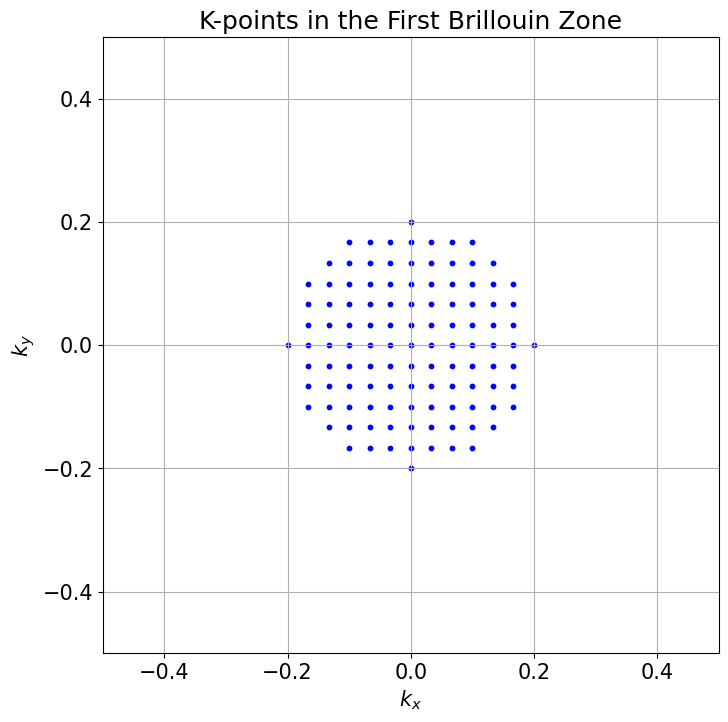

COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
(set! num-bands 12)
(set! resolution 32)
(set! k-points (list (vector3 0.0 -0.2 0.0) (vector3 -0.09999999999999998 -0.16666666666666669 0.0) (vector3 -0.06666666666666665 -0.16666666666666669 0.0) (vector3 -0.033333333333333326 -0.16666666666666669 0.0) (vector3 0.0 -0.16666666666666669 0.0) (vector3 0.033333333333333326 -0.16666666666666669 0.0) (vector3 0.06666666666666665 -0.16666666666666669 0.0) (vector3 0.09999999999999998 -0.16666666666666669 0.0) (vector3 -0.13333333333333336 -0.13333333333333336 0.0) (vector3 -0.09999999999999998 -0.13333333333333336 0.0) (vector3 -0.06666666666666665 -0.13333333333333336 0.0) (vector3 -0.033333333333333326 -0.13333333333333336 0.0) (vector3 0.0 -0.13333333333333336 0.0) (vector3 0.033333333333333326 -0.13333333333333336 0.0) (vector3 0.06666666666666665 -0.13333333333333336 0.0) (vector3 0.09999999999999998 -0.13333333333333336 0.0) (vector3 0.13333333333333

In [3]:


T = 4
n_InP = 3.075*(1+2.7e-5*T)
print(n_InP)
eps = round(n_InP**2,2)
print("Epsilon of InP: ", eps)
InP = Material(epsilon = eps)
air = Material(epsilon = 1)
## Simulation Name: 
name = "C4v_diatomic_T4"

## Define the geometry
radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice

lattice_2D = SquareLattice()



center = mp.Vector3(0,0,0)
geom = BaseDielectricDistribution(eps_bulk = eps).make_C4v_diatomic_B()
photonic_crystal = PhotonicCrystal(lattice=lattice_2D, atoms=geom)



# Generate k-points in the irreducible Brillouin zone
nx, ny = 51, 51
# kpoints_array = generate_bz_kpoints(nx, ny, centered=True)
kpoints_array = generate_circle_k_points(resolution=31, radius=0.2)
kpoints = make_kpoints_vector3(kpoints_array)

# plot the k-points 
plt.figure(figsize=(8, 8))
plt.scatter(kpoints_array[:, 0], kpoints_array[:, 1], marker='o', color='blue', s=10)
plt.xlim(-0.5, 0.5)
plt.ylim(-0.5, 0.5)
plt.xlabel(r'$k_x$')
plt.ylabel(r'$k_y$')
plt.title('K-points in the First Brillouin Zone')
plt.grid()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

## Define the simulation
configuration_options= dict(
    resolution = 32, 
    num_bands=12,
    k_points=kpoints,
    k_points_interpolation_factor=None,
    
)



mpb_configuration = MPBSchemeConfigurator(photonic_crystal, ["te", "tm"], **configuration_options)
script = mpb_configuration.get_scheme_config(join_newline=True)

name = "band3D"

data_rooth = "/work3/s232699/phc_nzi/data/"

simulation = Simulation(
    simulation_name=name,
    script = script,
    directory= os.path.join(data_rooth, name)
    )

numproc= 32
pop = numproc // 2
lsf_config = LSFJobConfiguration(num_processors=numproc, span_option="block", span_value=8, queue="fotonano")


print(script)





In [4]:
r1 = 0.24
r2 = 0.2344
#simulation.run_hpc_lsf(mpb_command_line_params=dict(r1=r1, r2=r2), LSFOptions=lsf_config)
viewer = SimulationViewer(simulation)
#viewer.plot_epsilon_2d()
df = simulation.load_frequency_data("te")
display(df)

,k index,k1,k2,k3,kmag/2pi,te band 1,te band 2,te band 3,te band 4,te band 5,te band 6,te band 7,te band 8,te band 9,te band 10,te band 11,te band 12
0,1,0.000000,-0.200000,0,0.200000,0.087277,0.331773,0.403493,0.502449,0.531469,0.565262,0.595578,0.644263,0.664372,0.768619,0.809420,0.812835
1,2,-0.100000,-0.166667,0,0.194365,0.084578,0.338420,0.396258,0.501224,0.537362,0.559643,0.607751,0.629265,0.668339,0.766700,0.816776,0.823948
2,3,-0.066667,-0.166667,0,0.179505,0.078238,0.340418,0.398935,0.505229,0.533608,0.556981,0.603897,0.633412,0.663795,0.770506,0.818103,0.820797
3,4,-0.033333,-0.166667,0,0.169967,0.074171,0.341472,0.400904,0.507817,0.530944,0.555572,0.601372,0.636716,0.660270,0.773115,0.816624,0.820778
4,5,0.000000,-0.166667,0,0.166667,0.072765,0.341798,0.401631,0.508719,0.529979,0.555133,0.600488,0.638083,0.658831,0.774060,0.815769,0.821046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,109,0.000000,0.166667,0,0.166667,0.072766,0.341818,0.401652,0.508749,0.529985,0.555083,0.600559,0.638029,0.658773,0.774083,0.815758,0.821128
109,110,0.033333,0.166667,0,0.169967,0.074172,0.341492,0.400937,0.507858,0.530937,0.555523,0.601431,0.636687,0.660186,0.773143,0.816612,0.820862
110,111,0.066667,0.166667,0,0.179505,0.078239,0.340437,0.398980,0.505281,0.533589,0.556933,0.603944,0.633396,0.663698,0.770537,0.818144,0.820830
111,112,0.100000,0.166667,0,0.194365,0.084578,0.338437,0.396313,0.501284,0.537333,0.559595,0.607791,0.629252,0.668236,0.766731,0.816865,0.823935


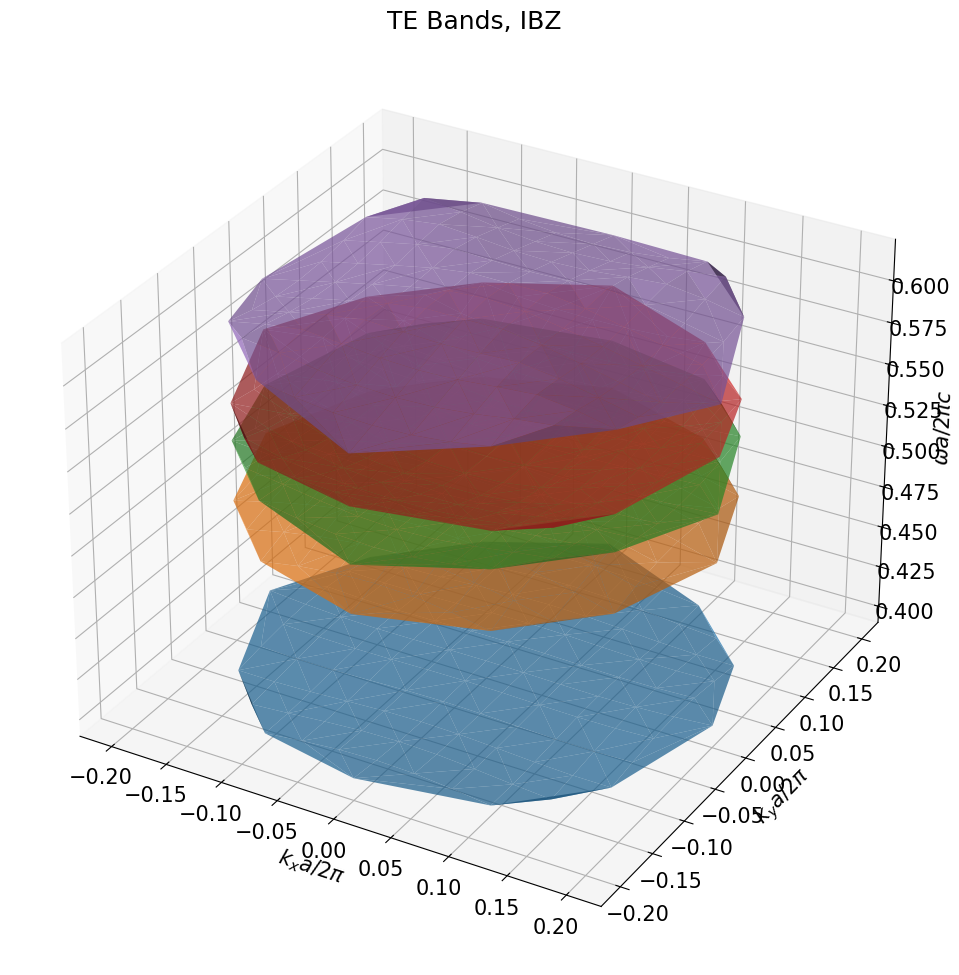

In [5]:
def plot_bands_surface_IBZ(df, bands: None| list=None, theta: float = None, phi: float = None):
    """
    Create a 3D surface plot of TE bands vs. k1 and k2.

    Parameters:
    -----------
    df : pandas.DataFrame
        Must contain columns 'k1', 'k2' and one or more 'te band X' columns.
    bands : list of str, optional
        Specific TE band columns to plot. If None, all 'te band X' columns will be plotted.
    """
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    band_cols = []
    if bands is None:
        # Automatically find all columns that start with 'te band'
        band_cols = [col for col in df.columns if col.startswith('te band')]
    else:
        # Use the provided list of bands
        for band in bands:
            band_cols.append(f'te band {band}')
    # Create a surface for each band using trisurf (handles irregular grids)
    for band in band_cols:
        surf = ax.plot_trisurf(df['k1'], df['k2'], df[band], 
                               linewidth=0.2, antialiased=True, alpha=0.7, label=band)
    
    ax.set_xlabel('$k_x a/2\pi$')
    ax.set_ylabel('$k_y a/2\pi$')
    ax.set_zlabel('$\omega a/2\pi c$')
    ax.set_title('TE Bands, IBZ')
    plt.tight_layout(w_pad=0.5)
    
    # rotate the view
    if theta is not None and phi is not None:
        ax.view_init(elev=theta, azim=phi)
    
    # Note: legend for plot_trisurf may not display; if needed, add a proxy artist.
    
    plt.show()

# Example usage:

plot_bands_surface_IBZ(df, [3,4,5,6, 7])




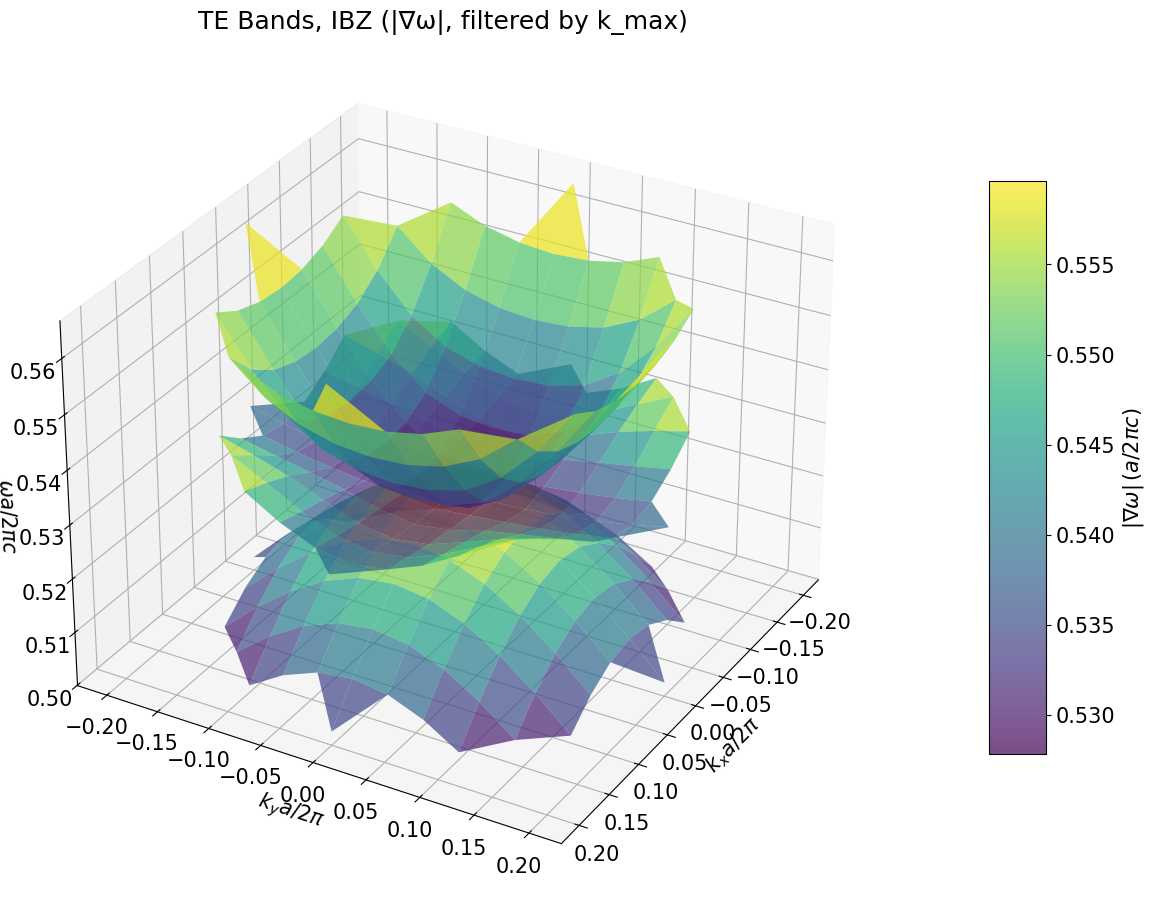

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def plot_bands_surface_IBZ(df, bands=None, theta=None, phi=None, k_max=None):
    """
    3D TE-band surfaces colored by |∇ω|, with optional kmag/2π cutoff.
    """
    # 1) apply k_max filter
    if k_max is not None:
        df = df[df["kmag/2pi"] <= k_max]

    # 2) pick bands
    if bands is None:
        band_cols = [c for c in df.columns if c.startswith("te band")]
    else:
        band_cols = [f"te band {b}" for b in bands]

    fig = plt.figure(figsize=(12,10))
    ax  = fig.add_subplot(111, projection="3d")

    for band in band_cols:
        # pivot onto a regular 2D grid
        pivot = df.pivot(index="k2", columns="k1", values=band)
        k2_vals = pivot.index.values
        k1_vals = pivot.columns.values
        Z       = pivot.values


        # flatten back for trisurf
        K1, K2 = np.meshgrid(k1_vals, k2_vals)
        

        surf = ax.plot_surface(K1, K2, Z, 
                               linewidth=0.2, antialiased=True, alpha=0.7,
                               cmap=cm.viridis, label=band)

    ax.set_xlabel('$k_x a/2\pi$')
    ax.set_ylabel('$k_y a/2\pi$')
    ax.set_zlabel('$\omega a/2\pi c$')
    ax.set_title('TE Bands, IBZ (|∇ω|, filtered by k_max)')

    if theta is not None and phi is not None:
        ax.view_init(elev=theta, azim=phi)

    cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10, pad=0.1)
    cbar.set_label(r'$|\nabla \omega|\, (a/2\pi c)$')

    plt.tight_layout()
    plt.show()




# Example usage:
plot_bands_surface_IBZ(df, [4,5,6], theta=30, phi=30, k_max= None)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from scipy.interpolate import griddata
np.set_printoptions(threshold=sys.maxsize)
from matplotlib._layoutgrid import plot_children

%matplotlib inline
%config InlineBackend.figure_format = 'svg'           # crisp lines
%config InlineBackend.print_figure_kwargs = {'dpi': 150}

plt.rcParams.update(plt.rcParamsDefault)  # reset to defaults
plt.rcParams["font.size"] = 18


%config InlineBackend.figure_format = 'svg'
def _plot_band_with_interp(ax, k1_vals, k2_vals, Z,
                           cmap, norm, N=150, k_max=None):
    """
    Interpolate Z(k1,k2) → smooth grid.  If k_max is given,
    build the grid in (r,φ) so that points lie on a circle of radius k_max.
    """
    # 1) original points, drop NaNs
    K1, K2 = np.meshgrid(k1_vals, k2_vals)
    pts  = np.vstack([K1.ravel(), K2.ravel()]).T
    vals = Z.ravel()
    mask = ~np.isnan(vals)
    pts, vals = pts[mask], vals[mask]

    # 2) build a circular grid if k_max provided, else rectangular
    if k_max is not None:
        # polar grid
        r   = np.linspace(0, k_max, N)
        phi = np.linspace(0, 2*np.pi, N)
        R, Phi = np.meshgrid(r, phi)
        XI = (R * np.cos(Phi))
        YI = (R * np.sin(Phi))
    else:
        # Cartesian grid
        xi = np.linspace(k1_vals.min(), k1_vals.max(), N)
        yi = np.linspace(k2_vals.min(), k2_vals.max(), N)
        XI, YI = np.meshgrid(xi, yi)

    # 3) interpolate (cubic + nearest fallback)
    ZI = griddata(pts, vals, (XI, YI), method='cubic')
    # if np.any(np.isnan(ZI)):
    #     ZI_nn = griddata(pts, vals, (XI, YI), method='nearest')
    #     ZI[np.isnan(ZI)] = ZI_nn[np.isnan(ZI)]

    # 4) plot with facecolors from shared norm/cmap
    surf = ax.plot_surface(
        XI, YI, ZI,
        facecolors=cm.get_cmap(cmap)( norm(ZI) ),
        rcount=N, ccount=N,
        linewidth=0, antialiased=False, shade=False, alpha=0.9,
        edgecolor="none",   
    )
    return surf


def plot_bands_surface_IBZ(
    df,
    bands: None| list=None,
    theta: float = None,
    phi: float = None,
    k_max: float = None,
    highlight_freq: float = None,
    cmap: str = "coolwarm",
    N: int = 100,
):
    """
    3D TE-band surfaces colored by ω, with a single shared colorbar
    and an optional highlighted frequency ω₀ at the map center.
    """
    # 1) filter by k_max
    if k_max is not None:
        df = df[df["kmag/2pi"] <= k_max]

    # 2) pick your band columns
    if bands is None:
        band_cols = sorted(c for c in df.columns if c.startswith("te band"))
    else:
        band_cols = [f"te band {i}" for i in bands]

    # 3) compute global ω-min and ω-max across *all* bands
    all_mins, all_maxs = [], []
    for band in band_cols:
        Z = df.pivot(index="k2", columns="k1", values=band).values
        all_mins.append(np.nanmin(Z))
        all_maxs.append(np.nanmax(Z))
    global_min = min(all_mins)
    global_max = max(all_maxs)

    # 4) set up a single Normalization
    if highlight_freq is not None:
        norm = TwoSlopeNorm(vmin=global_min,
                            vcenter=highlight_freq,
                            vmax=global_max)
    else:
        # linear from min→max
        from matplotlib.colors import Normalize
        norm = Normalize(vmin=global_min, vmax=global_max)

    # 5) plot all surfaces with the same cmap & norm
    fig = plt.figure(figsize=(12, 10), constrained_layout=False)
    gs = fig.add_gridspec(1, 1, left=0.3, right=0.9, wspace = 0.1)
    ax = fig.add_subplot(gs[0, 0], projection="3d")


    print(fig.get_children())

    for band in band_cols:
        pivot = df.pivot(index="k2", columns="k1", values=band)
        k2_vals, k1_vals = pivot.index.values, pivot.columns.values
        Z = pivot.values

        _plot_band_with_interp(
        ax, k1_vals, k2_vals, Z,
        cmap, norm,
        N=N,
        k_max=k_max
        )

    
        

    # 6) labels & view
    ax.set_xlabel('$k_x a/2\pi$')
    ax.set_ylabel('$k_y a/2\pi$')
    ax.set_zlabel('$\omega a/2\pi c$')
    ax.set_title('TE Bands forming the Dirac Like Cone, \n 2D Photonic Crystal')

    if theta is not None and phi is not None:
        ax.view_init(elev=theta, azim=phi)

    # 7) single shared colorbar
    mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array([])    # no data needed here
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.6, aspect=10, pad=0.02)
    cbar.set_label('$\omega\, (a/2\pi c)$')
    plt.grid(False)
    fig.set_layout_engine('none')

    # 1) re-draw the colorbar with a smaller width and less pad:
    cbar.remove()  
    cbar = fig.colorbar(
        mappable,
        ax=ax,
        shrink=0.5,
        aspect=20,     # make it thinner (higher aspect ratio)
        pad=0.05       # tiny gap between axes and bar
    )
    cbar.set_label('$\\omega a/2\\pi c$')



    # 3) if your x-label is still hugging, add more labelpad:
    ax.xaxis.labelpad = 25
    ax.yaxis.labelpad = 25
    ax.zaxis.labelpad = 10
    fig = ax.get_figure()
    fig.set_size_inches(12, 8)
    fig.tight_layout()
    
    plt.show()
    



# Example usage:
omega_d = df[df["kmag/2pi"] == 0]["te band 5"].values[0]
plot_bands_surface_IBZ(df, [4,5,6], theta=15, phi=30, k_max=0.18, highlight_freq=omega_d, cmap = "Spectral")

[<matplotlib.patches.Rectangle object at 0x7ff7825958d0>, <Axes3D: >]


/tmp/pbs.542404.hnode41/ipykernel_4149101/1559167865.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  facecolors=cm.get_cmap(cmap)( norm(ZI) ),
/tmp/pbs.542404.hnode41/ipykernel_4149101/1559167865.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [9]:
import numpy as np
from scipy.interpolate import griddata
from mayavi import mlab

def _plot_band_with_interp_mayavi(k1_vals, k2_vals, Z, colormap, norm, N=150, k_max=None):
    """
    Interpolate Z(k1,k2) to a smooth grid, then plot with mayavi.mlab.mesh.
    """
    # 1) original points, drop NaNs
    K1, K2 = np.meshgrid(k1_vals, k2_vals)
    pts  = np.vstack([K1.ravel(), K2.ravel()]).T
    vals = Z.ravel()
    mask = ~np.isnan(vals)
    pts, vals = pts[mask], vals[mask]

    # 2) build circular or rectangular grid
    if k_max is not None:
        r   = np.linspace(0, k_max, N)
        phi = np.linspace(0, 2*np.pi, N)
        R, Phi = np.meshgrid(r, phi)
        XI = (R * np.cos(Phi))
        YI = (R * np.sin(Phi))
    else:
        XI = np.linspace(k1_vals.min(), k1_vals.max(), N)
        YI = np.linspace(k2_vals.min(), k2_vals.max(), N)
        XI, YI = np.meshgrid(XI, YI)

    # 3) interpolate
    ZI = griddata(pts, vals, (XI, YI), method='cubic')
    # fallback to nearest for any remaining NaNs
    if np.any(np.isnan(ZI)):
        ZI_nn = griddata(pts, vals, (XI, YI), method='nearest')
        ZI = np.where(np.isnan(ZI), ZI_nn, ZI)

    # 4) plot with mayavi
    surf = mlab.mesh(
        XI, YI, ZI,
        colormap=colormap,
        scalars=ZI,
    )
    # apply the same normalization
    surf.module_manager.scalar_lut_manager.data_range = (norm.vmin, norm.vmax)
    surf.module_manager.scalar_lut_manager.use_default_name = False
    surf.module_manager.scalar_lut_manager.lut_mode = colormap
    return surf

def plot_bands_surface_mayavi(
    df,
    bands=None,
    theta=15, phi=30,
    k_max=None,
    highlight_freq=None,
    colormap="Spectral",
    N=150
):
    """
    Render TE band surfaces in Mayavi, colored by ω, optionally highlighting
    a center frequency.
    """
    # 1) filter by k_max
    if k_max is not None:
        df = df[df["kmag/2pi"] <= k_max]

    # 2) select bands
    if bands is None:
        band_cols = sorted(col for col in df.columns if col.startswith("te band"))
    else:
        band_cols = [f"te band {i}" for i in bands]

    # 3) compute global ω-min/max
    all_mins, all_maxs = [], []
    for band in band_cols:
        Z = df.pivot(index="k2", columns="k1", values=band).values
        all_mins.append(np.nanmin(Z))
        all_maxs.append(np.nanmax(Z))
    vmin, vmax = min(all_mins), max(all_maxs)

    # 4) setup norm
    from matplotlib.colors import TwoSlopeNorm, Normalize
    if highlight_freq is not None:
        norm = TwoSlopeNorm(vmin=vmin, vcenter=highlight_freq, vmax=vmax)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    # 5) create a new figure
    mlab.figure(size=(1200, 800), bgcolor=(1,1,1))

    # 6) plot each band
    for band in band_cols:
        piv = df.pivot(index="k2", columns="k1", values=band)
        k2_vals, k1_vals = piv.index.values, piv.columns.values
        Z = piv.values
        _plot_band_with_interp_mayavi(
            k1_vals, k2_vals, Z,
            colormap, norm,
            N=N, k_max=k_max
        )

    # 7) adjust view
    mlab.view(azimuth=phi, elevation=theta, distance='auto')
    mlab.axes(xlabel='$k_x a/2\pi$', ylabel='$k_y a/2\pi$', zlabel='$\omega a/2\pi c$')
    mlab.title('TE Bands forming the Dirac‐Like Cone\n2D Photonic Crystal', height=0.85, size=0.4)

    # 8) add colorbar
    mlab.colorbar(title='$\omega\, (a/2\pi c)$', orientation='vertical', nb_labels=5, label_format="%.3f")

    mlab.show()

# Example usage:
omega_d = df[df["kmag/2pi"] == 0]["te band 5"].values[0]
plot_bands_surface_mayavi(
    df,
    bands=[4,5,6],
    theta=15, phi=30,
    k_max=0.18,
    highlight_freq=omega_d,
    colormap="Spectral"
)



ImportError: cannot import name 'Font' from 'traits.api' (/zhome/2f/7/202918/miniconda3/envs/nzi-mp/lib/python3.11/site-packages/traits/api.py)

In [19]:
# find line of df where kmag/2pi =0
df[df["kmag/2pi"] == 0]

#find the value of te band 5 at kmag/2pi =0
df[df["kmag/2pi"] == 0]["te band 5"].values[0]

0.526561

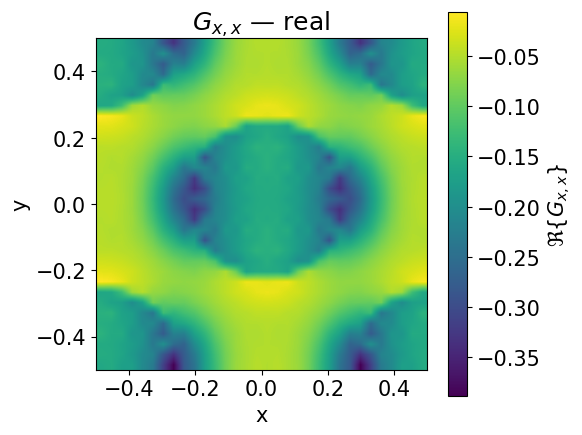

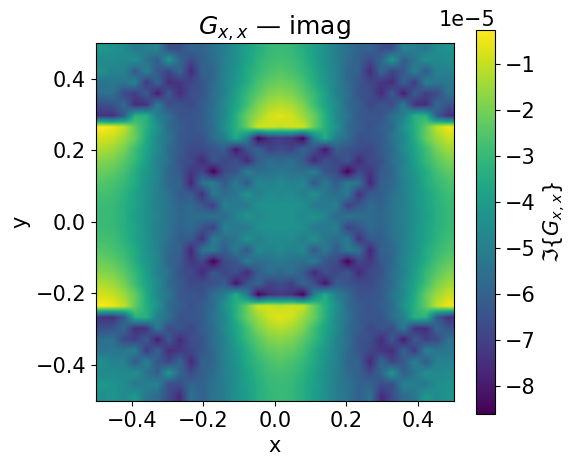

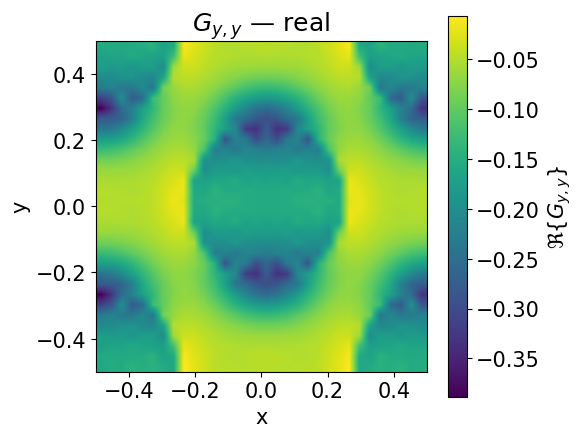

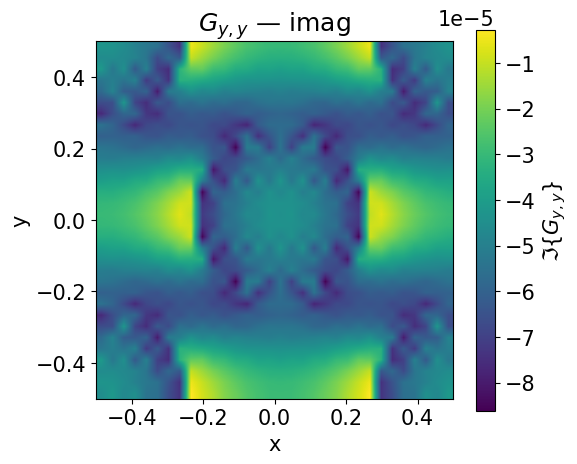

In [44]:
import os
import numpy as np

def compute_green_tensor(u0, df, simulation,  gamma=1e-6):
    """
    Compute the MPB-normalized Green's tensor G_{ij}(r; u0) 
    on the simulation grid. Returns an array of shape (3,3,Nx,Ny,Nz).
    """
    k_indices = df["k index"].unique()
    Nk = len(k_indices)

    # Load one field to get the grid shape
    first_k = k_indices[0]
    first_band_col = next(col for col in df.columns if col.startswith("te band"))
    first_band = int(first_band_col.split()[-1])
    fname0 = f"{name}-e.k{first_k:02d}.b{first_band:02d}.te.h5"
    E0 = simulation.load_h5_data(os.path.join(simulation.directory, fname0))
    # build a (3, Nx, Ny, Nz) array for dimensions
    Ex0 = E0["x.r"] + 1j*E0["x.i"]
    Ey0 = E0["y.r"] + 1j*E0["y.i"]
    Ez0 = E0["z.r"] + 1j*E0["z.i"]
    grid_shape = Ex0.shape  # e.g. (Nx, Ny, Nz)

    # Initialize G tensor: 3×3 at every grid point
    G = np.zeros((3, 3) + grid_shape, dtype=complex)

    prefactor = 1.0 / (4 * np.pi**2 * Nk)

    for k_idx in k_indices:
        for col in df.columns:
            if not col.startswith("te band"):
                continue
            u_n = df.loc[df["k index"] == k_idx, col].item()
            band_idx = int(col.split()[-1])

            fname = f"{name}-e.k{k_idx:02d}.b{band_idx:02d}.te.h5"
            Edata = simulation.load_h5_data(os.path.join(simulation.directory, fname))
            Ex = Edata["x.r"] + 1j*Edata["x.i"]
            Ey = Edata["y.r"] + 1j*Edata["y.i"]
            Ez = Edata["z.r"] + 1j*Edata["z.i"]

            # stack into shape (3, Nx, Ny, Nz)
            E_vec = np.stack((Ex, Ey, Ez), axis=0)

            # denominator at this band/k-point
            denom = (u0**2 - u_n**2) + 1j*gamma

            # dyadic product at each point: broadcast E_vec[:,None,...]*E_vec[None,...].conj()
            # This gives an array shape (3,3,Nx,Ny,Nz)
            dyad = E_vec[:, None, ...] * np.conj(E_vec[None, :, ...])

            # accumulate into G
            G += prefactor * dyad / denom

    return G



def plot_G_component_xy(G, x, y, component=(0,0), cmap='viridis',
                               plot_type='real', interpolation='bilinear'):
    """
    Plot the G_ij component of the Green's tensor over the x–y plane at fixed z,
    using imshow with interpolation for a smoother appearance.
    """
    i, j = component
    data = G[i, j, :, :]
    
    if plot_type == 'real':
        data_to_plot = np.real(data)
        label = f'$\\Re\\{{G_{{{["x","y","z"][i]},{["x","y","z"][j]}}}\\}}$'
    elif plot_type == 'imag':
        data_to_plot = np.imag(data)
        label = f'$\\Im\\{{G_{{{["x","y","z"][i]},{["x","y","z"][j]}}}\\}}$'
    else:
        data_to_plot = np.abs(data)
        label = f'$|G_{{{["x","y","z"][i]},{["x","y","z"][j]}}}|$'
    
    # Set up extent so imshow maps pixels to your physical x/y coordinates
    extent = (x.min(), x.max(), y.min(), y.max())
    
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(data_to_plot.T,        # note the transpose
                   origin='lower',
                   extent=extent,
                   interpolation=interpolation,
                   aspect='equal',
                   cmap=cmap)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'$G_{{{["x","y","z"][i]}, {["x","y","z"][j]}}}$ — {plot_type}')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(label)
    plt.tight_layout()
    return fig, ax

G = compute_green_tensor(0.3, df, simulation)
Nx, Ny = G.shape[2:] 
x = np.linspace(-0.5, 0.5, Nx)
y = np.linspace(-0.5, 0.5, Ny)

fig, ax = plot_G_component_xy(G, x, y, component=(0,0), cmap='viridis', plot_type='real')
fig, ax = plot_G_component_xy(G, x, y, component=(0,0), cmap='viridis', plot_type='imag')

fig, ax = plot_G_component_xy(G, x, y, component=(1,1), cmap='viridis', plot_type='real')
fig, ax = plot_G_component_xy(G, x, y, component=(1,1), cmap='viridis', plot_type='imag')

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import os

def find_nearest_index(arr, value):
    """Return the index of the element in arr closest to value."""
    return np.abs(arr - value).argmin()

def compute_G_at_points(u0, df, simulation, r1: list[int, int], r2: list[int, int], gamma=np.finfo(np.float32).eps, name=name):
    """
    Compute G_ij(r1*,r2*; u0).
    Returns a 3x3 complex array.
    """
    i = 0
    k_indices = df["k index"].unique()
    Nk = len(k_indices)
    prefactor = 1.0 / (4 * np.pi**2 * Nk)
    ix1, iy1  = r1
    ix2, iy2  = r2
    gamma_idx = df["kmag/2pi"].idxmin()
    

    G_pt = np.zeros((3,3), dtype=complex)
    band_cols = [c for c in df.columns if c.startswith("te band")]
    for k_idx in k_indices:
        for col in band_cols:
            u_n = df.loc[df["k index"] == k_idx, col].item()
            band_idx = int(col.split()[-1])
            fname = f"{simulation.simulation_name}-e.k{k_idx:02d}.b{band_idx:02d}.te.h5"
            Edata = simulation.load_h5_data(os.path.join(simulation.directory, fname))

            # pull out the field at the one point
            Ex1 = Edata["x.r"][ix1,iy1] + 1j*Edata["x.i"][ix1,iy1]
            Ey1 = Edata["y.r"][ix1,iy1] + 1j*Edata["y.i"][ix1,iy1]
            Ez1 = Edata["z.r"][ix1,iy1] + 1j*Edata["z.i"][ix1,iy1]

            Ex2 = Edata["x.r"][ix2,iy2] + 1j*Edata["x.i"][ix2,iy2]
            Ey2 = Edata["y.r"][ix2,iy2] + 1j*Edata["y.i"][ix2,iy2]
            Ez2 = Edata["z.r"][ix2,iy2] + 1j*Edata["z.i"][ix2,iy2]

            # if k_idx == gamma_idx and i==0:
            #     plt.imshow(np.abs(Edata["x.r"]), origin='lower', interpolation='bilinear')
            #     plt.scatter(ix1, iy1, color='red', label='r1')
            #     plt.scatter(ix2, iy2, color='blue', label='r2')
            #     plt.colorbar(label='|E_x|') 
            #     plt.show()
            #     i+=1


            E_vec1 = np.array([Ex1, Ey1, Ez1])
            E_vec2 = np.array([Ex2, Ey2, Ez2])
            denom = (u0**2 - u_n**2) + 1j*gamma
            dyad = np.outer(E_vec1, np.conj(E_vec2))
            G_pt += prefactor * dyad / denom

    return G_pt

# --- USER CHOICES ---
# physical coordinates of r* in units of the lattice constant a/N:
r1  = [15, 0]
r2 =  r1

w_list = np.linspace(0.52, 0.56, 200)
G_array = []
for w in w_list:
    G_pt = compute_G_at_points(w, df, simulation, r1, r2)
    G_comp = G_pt[0,0]
    G_array.append(G_comp)
    




The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


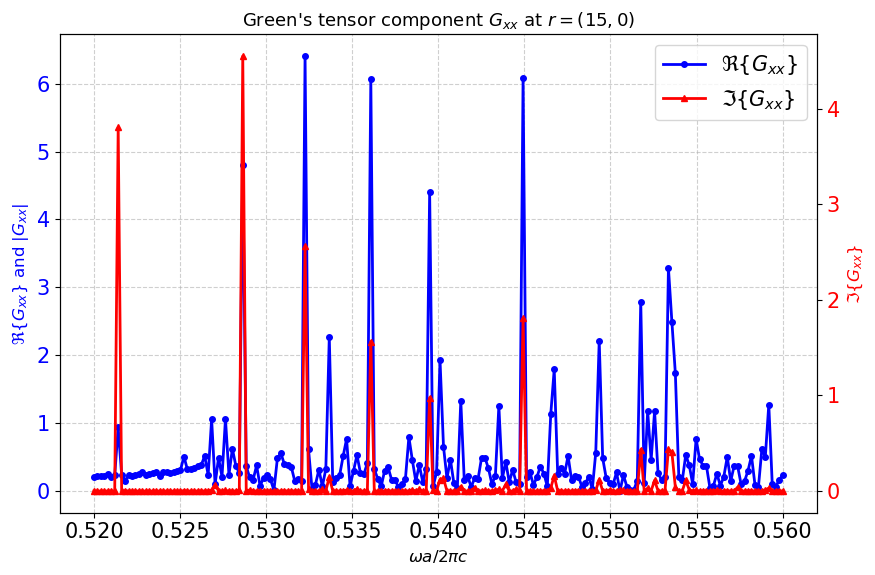

In [51]:
# --- PLOTTING ---
comp = (0,0)    
fig, ax1 = plt.figure(figsize=(9,6)), plt.gca()
# Plot real part and magnitude on left axis
ax1.plot(w_list, np.abs(np.real(G_array)), 'o-', color='blue', linewidth=2, 
         markersize=4, label=r'$\Re\{G_{xx}\}$')

ax1.set_xlabel('$\omega a/2\pi c$', fontsize=12)
ax1.set_ylabel(r'$\Re\{G_{xx}\}$ and $|G_{xx}|$', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.6)
# ax1.set_yscale("log")
# Create second y-axis for imaginary part
ax2 = ax1.twinx()
ax2.plot(w_list, np.abs(np.imag(G_array)), '^-', color='red', linewidth=2, 
         markersize=4, label=r'$\Im\{G_{xx}\}$')
ax2.set_ylabel(r'$\Im\{G_{xx}\}$', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Add combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
# plt.yscale("log")
plt.title(f"Green's tensor component $G_{{xx}}$ at $r = ({r1[0]}, {r1[1]})$", fontsize=13)
plt.tight_layout()

plt.show()

In [54]:
w_n = df.loc[df["kmag/2pi"] == 0, "te band 5"].item()
print("w_n: ", w_n)   

w_n:  0.526561
